<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys

# Install Torch
!{sys.executable} -m pip install torch torchvision torchaudio

# Install Ultralytics (YOLO)
!{sys.executable} -m pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.__version__)

from ultralytics import YOLO
print("YOLO installed successfully")

2.10.0+cpu
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO installed successfully



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 176.1ms
Speed: 3.9ms preprocess, 176.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


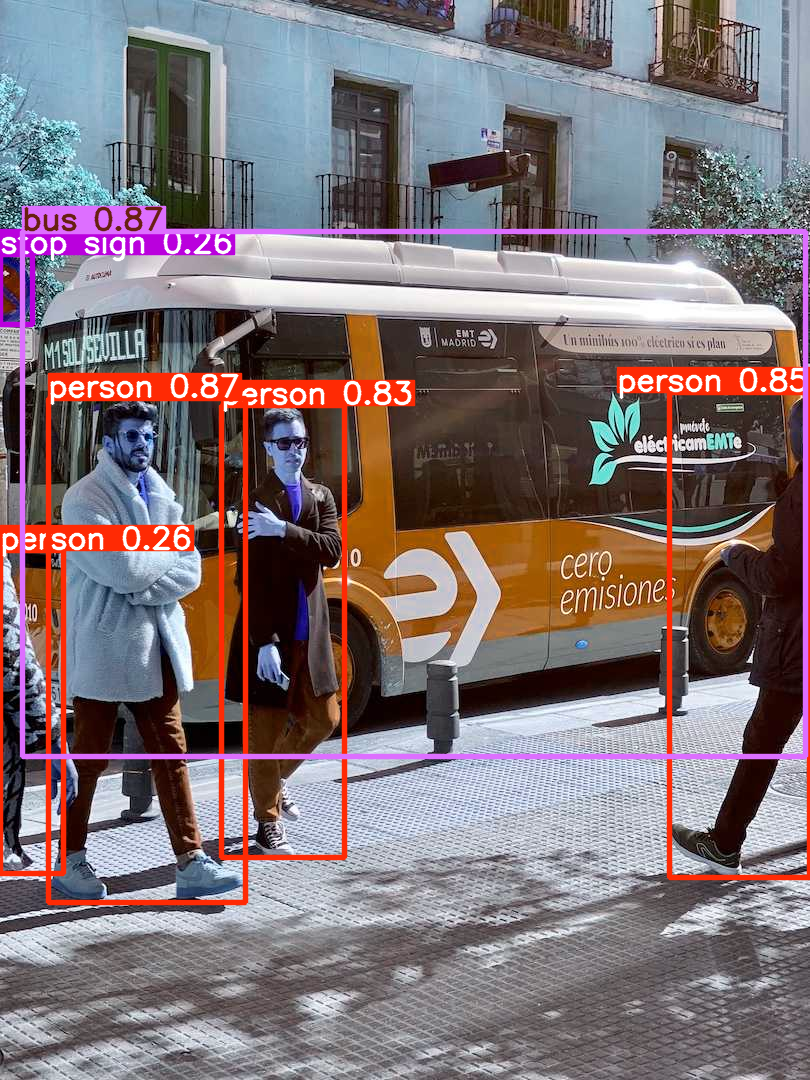

In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

# Load YOLO model
model = YOLO("yolov8n.pt")

# Detect objects
results = model("https://ultralytics.com/images/bus.jpg")

# Show output image
img = results[0].plot()

display(Image.fromarray(img))

Saving exp8.jpg to exp8.jpg

image 1/1 /content/exp8.jpg: 384x640 4 persons, 2 buss, 1 truck, 1 umbrella, 1 tie, 156.8ms
Speed: 2.9ms preprocess, 156.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


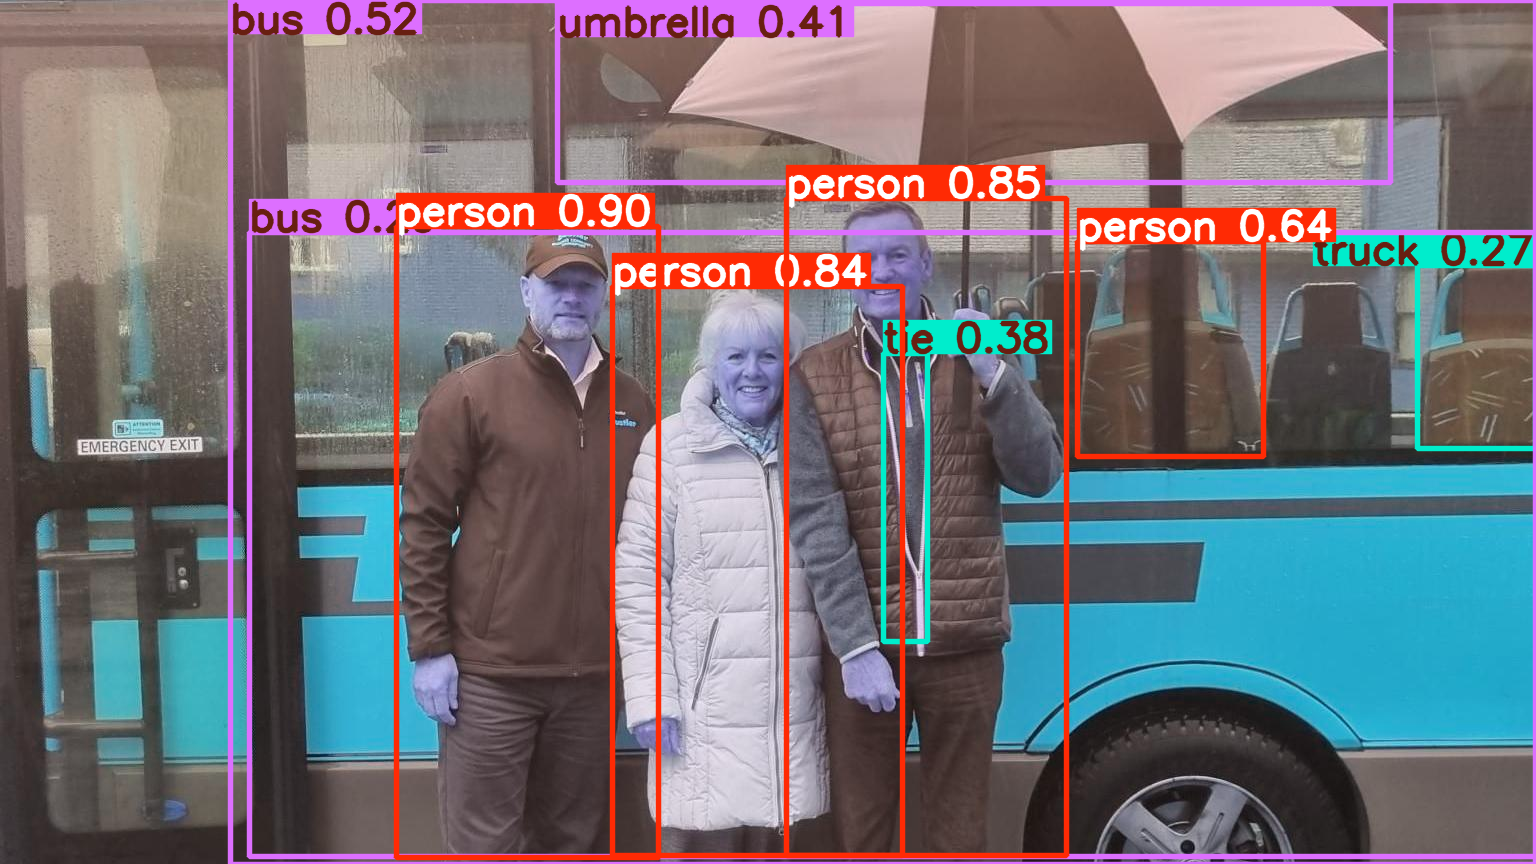

In [ ]:
from google.colab import files
uploaded = files.upload()

from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# Load model
model = YOLO("yolov8n.pt")

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Run detection
results = model(filename)

# Plot output
img = results[0].plot()

# Display result
display(Image.fromarray(img))

In [ ]:
from ultralytics import YOLO
import cv2
import random
from google.colab import files

# Upload video
uploaded = files.upload()

# Get uploaded filename
video_path = list(uploaded.keys())[0]

# Load model
model = YOLO("yolov8n.pt")

# Open video
cap = cv2.VideoCapture(video_path)

# Video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Save output
out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h)
)

# Random color
def get_color(cls_id):
    random.seed(cls_id)
    return tuple(random.randint(0,255) for _ in range(3))

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)

    for result in results:

        for box in result.boxes:

            if box.conf[0] > 0.4:

                x1, y1, x2, y2 = map(int, box.xyxy[0])

                cls = int(box.cls[0])

                conf = float(box.conf[0])

                color = get_color(cls)

                # Rectangle
                cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

                # Label
                label = f"{result.names[cls]} {conf:.2f}"

                cv2.putText(
                    frame,
                    label,
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    color,
                    2
                )

    out.write(frame)

cap.release()
out.release()

print("Output video saved as output.mp4")

Saving t1.mp4 to t1.mp4

0: 384x640 19 persons, 19 cars, 3 motorcycles, 2 buss, 147.0ms
Speed: 6.1ms preprocess, 147.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 21 persons, 19 cars, 2 motorcycles, 2 buss, 170.1ms
Speed: 4.4ms preprocess, 170.1ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 19 cars, 2 motorcycles, 2 buss, 238.3ms
Speed: 10.9ms preprocess, 238.3ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 21 persons, 21 cars, 1 motorcycle, 2 buss, 221.9ms
Speed: 4.9ms preprocess, 221.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 20 persons, 20 cars, 2 motorcycles, 2 buss, 221.5ms
Speed: 6.0ms preprocess, 221.5ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 persons, 20 cars, 1 motorcycle, 2 buss, 217.5ms
Speed: 5.1ms preprocess, 217.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 3